In [17]:
import numpy as np
from sklearn.linear_model import RidgeCV as ridge
from sklearn.model_selection import train_test_split
from tqdm import trange,tqdm
import pickle
import matplotlib.pyplot as plt
from math import ceil
import scipy
import scipy.signal
import itertools
import sys, os
import scipy.stats as sts
from scipy.stats import sem 
from sklearn.linear_model import Ridge, LogisticRegression
from scipy.stats import pearsonr, sem
import pickle
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import ssm
from ssm.util import find_permutation
import pandas as pd
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler
import ast
from sklearn.model_selection import StratifiedKFold
from typing import Dict, Tuple, List

In [18]:
with open('C:/Users/shahe/PycharmProjects/distributed_SD/Data/predicted_trial_SVM_res_04_04.pkl', 'rb') as f:
    data_neural = pickle.load(f)

In [29]:
data_neural[0].columns

Index(['trial', 'taskTrial', 'bhvTrial', 'condition', 'task', 'outcome',
       'correct', 'reactionTime', 'numRewards', 'rule', 'ruleCue', 'cue',
       'color', 'direction', 'colorCoherence', 'motionCoherence',
       'expectedResponse', 'chosenResponse', 'choseExpected', 'trialStart',
       'fixptOn', 'fixationTime', 'fixTimeAlign', 'cueOn', 'cueOff', 'stimOn',
       'responseTime', 'responseDone', 'responseHeld', 'targetsOff',
       'outcomeTime', 'rewardOn', 'rewardOff', 'feedbackOff', 'trialEnd',
       'session', 'trialRefTimes', 'badTimingTrials', 'badTrials', 'color_raw',
       'direction_raw', 'color_lvl', 'direction_lvl', 'previous_color_lvl',
       'previous_direction_lvl', 'color_cat', 'direction_cat',
       'previous_color_cat', 'previous_direction_cat', 'response',
       'previous_response', 'context_response', 'previous_context_response',
       'predicted_response_PFC', 'predicted_previous_response_PFC',
       'predicted_color_cat_PFC', 'predicted_direction_cat

In [19]:
def map_predicted_labels_to_raw(data_list):
    new_data_list = []
    for df in data_list:

        
        # Build mappings from labels to raw values
        color_map = (
            df.dropna(subset=['color', 'color_raw'])
              .drop_duplicates(subset=['color'])
              .set_index('color')['color_raw']
              .to_dict()
        )
        direction_map = (
            df.dropna(subset=['direction', 'direction_raw'])
              .drop_duplicates(subset=['direction'])
              .set_index('direction')['direction_raw']
              .to_dict()
        )
        prev_color_map = (
            df.dropna(subset=['previous_color', 'previous_color_raw'])
              .drop_duplicates(subset=['previous_color'])
              .set_index('previous_color')['previous_color_raw']
              .to_dict()
        )
        prev_direction_map = (
            df.dropna(subset=['previous_direction', 'previous_direction_raw'])
              .drop_duplicates(subset=['previous_direction'])
              .set_index('previous_direction')['previous_direction_raw']
              .to_dict()
        )

        # Define which mappings apply to which predicted variables
        mapping_dict = {
            'predicted_color': color_map,
            'predicted_direction': direction_map,
            'predicted_previous_color': prev_color_map,
            'predicted_previous_direction': prev_direction_map,
        }

        # Collect all new columns in a dict
        new_cols = {}
        for col in df.columns:
            for key, mapping in mapping_dict.items():
                if col.startswith(key):
                    new_cols[col + '_raw'] = df[col].map(mapping)

        # Concatenate all at once
        if new_cols:
            df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

        # Optional: defragment memory (creates a clean copy)
        df = df.copy()
        new_data_list.append(df)

    return new_data_list
mapped_data = map_predicted_labels_to_raw(data_neural)
data_neural = mapped_data

In [20]:
# --- helpers ---
def zscore(s: pd.Series) -> pd.Series:
    """Fast z-score that preserves index and avoids divide-by-zero."""
    m = s.mean()
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return (s - m)  # all zeros; fine for downstream use
    return (s - m) / sd


# --- main processing ---
def process_session_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    idx = df.index
    new = {}

    # ---------- Basic columns ----------
    new['intercept'] = pd.Series(1, index=idx)

    color_z  = zscore(df['color_raw'])
    direc_z  = zscore(df['direction_raw'])
    new['color_z_b']     = color_z
    new['direction_z_b'] = direc_z

    # explicit previous color/direction for behavior
    new['prev_color_b']     = color_z.shift(1).fillna(0)
    new['prev_direction_b'] = direc_z.shift(1).fillna(0)

    # you can keep these if used elsewhere, or drop if not needed
    new['p_color_z_b']     = color_z.shift(1).fillna(0)
    new['p_direction_z_b'] = direc_z.shift(1).fillna(0)

    new['dist_prev_current_color']  = (color_z - new['p_color_z_b']).abs()
    new['dist_prev_current_motion'] = (direc_z - new['p_direction_z_b']).abs()

    resp = df['chosenResponse'].fillna(0).astype(int)
    new['response']        = resp
    new['prev_response_b'] = resp.shift(1).fillna(0)

    # (everything context-related below can stay as is if you still need it elsewhere)
    ctx_b = df['rule'].astype(int).map({1: 1, 0: -1}).fillna(-1)
    new['context_b'] = ctx_b

    new['context_color_b']  = color_z * ctx_b
    new['context_motion_b'] = direc_z * ctx_b

    rel_b = color_z.where(ctx_b == 1, direc_z)
    irr_b = direc_z.where(ctx_b == 1, color_z)
    new['relevant_b']   = rel_b
    new['irrelevant_b'] = irr_b
    new['prev_rel_b']   = rel_b.shift(1).fillna(0)
    new['prev_irr_b']   = irr_b.shift(1).fillna(0)

    cue_dummies = pd.get_dummies(df['cue'], prefix='cue', drop_first=False).astype('int8')
    cue_dummies = cue_dummies.reindex(idx, fill_value=0)

    # ---------- per-area helper ----------
    def add_area(area: str):
        base = 'predicted_'
        need = [
            f'{base}color_{area}_raw', f'{base}direction_{area}_raw',
            f'{base}previous_color_{area}_raw', f'{base}previous_direction_{area}_raw',
            f'{base}response_{area}', f'{base}previous_response_{area}',
            f'{base}context_response_{area}',
        ]
        if not all(c in df.columns for c in need):
            return

        color  = zscore(df[f'{base}color_{area}_raw'])
        direc  = zscore(df[f'{base}direction_{area}_raw'])
        pcolor = zscore(df[f'{base}previous_color_{area}_raw'])
        pdirec = zscore(df[f'{base}previous_direction_{area}_raw'])

        ctx = df[f'{base}context_response_{area}'].map({1: 1, 0: -1})
        prev_ctx = ctx.shift(1)

        new[f'color_{area}']         = color
        new[f'direction_{area}']     = direc
        # explicit neural previous color/direction
        new[f'prev_color_{area}']     = pcolor
        new[f'prev_direction_{area}'] = pdirec

        # keep old names if you want backward compatibility:
        new[f'p_color_{area}']     = pcolor
        new[f'p_direction_{area}'] = pdirec

        new[f'decodedResponse_{area}'] = df[f'{base}response_{area}']
        new[f'prev_response_{area}']   = df[f'{base}previous_response_{area}'].fillna(0)

        new[f'context_{area}']      = ctx
        new[f'prev_context_{area}'] = prev_ctx

        new[f'context_color_{area}']  = color * ctx
        new[f'context_motion_{area}'] = direc * ctx

        rel = color.where(ctx == 1, direc)
        irr = direc.where(ctx == 1, color)
        new[f'relevant_{area}']   = rel
        new[f'irrelevant_{area}'] = irr
        new[f'prev_rel_{area}']   = rel.shift(1).fillna(0)
        new[f'prev_irr_{area}']   = irr.shift(1).fillna(0)

    for area in ['PFC', 'FEF', 'LIP', 'V4', 'MT', 'IT', 'Parietal']:
        add_area(area)

    series_list = []
    for k, v in new.items():
        s = v if isinstance(v, pd.Series) else pd.Series(v, index=idx)
        if not s.index.equals(idx):
            s = s.reindex(idx)
        series_list.append(s.rename(k))
    new_df = pd.concat(series_list, axis=1)
    out = pd.concat([df, new_df, cue_dummies], axis=1)
    return out.copy()


# --- usage example ---
processed_data_neural = [process_session_data(df) for df in data_neural]



In [30]:
AREA_LIST = ['FEF', 'PFC', 'LIP', 'Parietal', 'V4', 'MT', 'IT']

# ---------- Feature builders (edit here to add/remove predictors) ----------

def build_X_behavior(df: pd.DataFrame) -> np.ndarray:
    """
    Behavior-only design matrix.
    Regressors: [color, direction, prev_color, prev_direction, prev_response, bias]
    """
    color_b        = -df[['color_z_b']].fillna(0).to_numpy()
    direction_b    = -df[['direction_z_b']].fillna(0).to_numpy()
    prev_color_b   = -df[['p_color_z_b']].fillna(0).to_numpy()
    prev_direction_b = -df[['p_direction_z_b']].fillna(0).to_numpy()
    prev_response_b  = -df[['prev_response_b']].fillna(0).to_numpy()
    context_color_b  = -df[['context_color_b']].fillna(0).to_numpy()
    context_motion_b = -df[['context_motion_b']].fillna(0).to_numpy()
    bias             = -df[['intercept']].fillna(0).to_numpy()

    X = np.hstack([
        color_b,
        direction_b,
        prev_color_b,
        prev_direction_b,
        prev_response_b,
        context_color_b,
        context_motion_b,
        bias,
    ])
    return X




def build_X_neural(df: pd.DataFrame, area: str) -> np.ndarray:
    """
    Neural-only design matrix for an area.
    Regressors: [color_n, direction_n, prev_color_n, prev_direction_n,
                 prev_response_n, context_color_n, context_motion_n, bias]
    """
    color_n         = -df[[f'color_{area}']].fillna(0).to_numpy()
    direction_n     = -df[[f'direction_{area}']].fillna(0).to_numpy()
    prev_color_n    = -df[[f'p_color_{area}']].fillna(0).to_numpy()
    prev_direction_n = -df[[f'p_direction_{area}']].fillna(0).to_numpy()
    prev_response_n = -df[[f'prev_response_{area}']].fillna(0).to_numpy()
    context_color_n = -df[[f'context_color_{area}']].fillna(0).to_numpy()
    context_motion_n = -df[[f'context_motion_{area}']].fillna(0).to_numpy()
    bias            = -df[['intercept']].fillna(0).to_numpy()

    X = np.hstack([
        #color_n,
        #direction_n,
        #prev_color_n,
        #prev_direction_n,
        prev_response_n,
        #context_color_n,
        #context_motion_n,
        bias,
    ])
    return X



def build_X_combined(df: pd.DataFrame, area: str) -> np.ndarray:
    """
    Combined behavior + neural.
    Behavior (no bias): [color, direction, prev_color, prev_direction, prev_response]
    Neural   (no bias): [color_n, direction_n, prev_color_n, prev_direction_n,
                         prev_response_n, context_color_n, context_motion_n]
    Single bias at the end.
    """
    # Behavior (no bias)
    color_b          = -df[['color_z_b']].fillna(0).to_numpy()
    direction_b      = -df[['direction_z_b']].fillna(0).to_numpy()
    prev_color_b     = -df[['p_color_z_b']].fillna(0).to_numpy()
    prev_direction_b = -df[['p_direction_z_b']].fillna(0).to_numpy()
    prev_response_b  = -df[['prev_response_b']].fillna(0).to_numpy()
    context_color_b  = -df[['context_color_b']].fillna(0).to_numpy()
    context_motion_b = -df[['context_motion_b']].fillna(0).to_numpy()


    # Neural (no bias)
    #color_n          = -df[[f'color_{area}']].fillna(0).to_numpy()
    #direction_n      = -df[[f'direction_{area}']].fillna(0).to_numpy()
    # prev_color_n     = -df[[f'p_color_{area}']].fillna(0).to_numpy()
    # prev_direction_n = -df[[f'p_direction_{area}']].fillna(0).to_numpy()
    prev_response_n  = -df[[f'prev_response_{area}']].fillna(0).to_numpy()
    # context_color_n  = -df[[f'context_color_{area}']].fillna(0).to_numpy()
    # context_motion_n = -df[[f'context_motion_{area}']].fillna(0).to_numpy()

    # Single bias
    bias             = -df[['intercept']].fillna(0).to_numpy()

    X = np.hstack([
        # behavior
        color_b, direction_b, prev_color_b, prev_direction_b, prev_response_b,context_color_b, context_motion_b,
        # neural
        #color_n, direction_n, #prev_color_n, prev_direction_n,
        prev_response_n, #context_color_n, context_motion_n,
        # bias
        bias
    ])
    return X




# ---------- Utilities ----------

def y_from_df(df: pd.DataFrame) -> np.ndarray:
    """Binary response as (T,1)."""
    return df['chosenResponse'].fillna(0).astype(int).to_numpy().reshape(-1, 1)

def sessions_with_area(processed_sessions, area: str):
    """Filter sessions that contain the required columns for an area."""
    required = {
        # f'color_{area}',
        # f'direction_{area}',
        # f'p_color_{area}',
        # f'p_direction_{area}',
        f'prev_response_{area}',
        # f'context_color_{area}',
        # f'context_motion_{area}',
        'intercept',  # shared
    }
    keep = []
    idxs = []
    for i, df in enumerate(processed_sessions):
        if required.issubset(set(df.columns)):
            keep.append(df)
            idxs.append(i)
    return keep, idxs


def prepare_sessionwise(dfs, X_builder, y_builder=y_from_df):
    """Return session-wise inpts, true_choices, and lengths with a builder function."""
    inpts, true_choices, lengths = [], [], []
    for df in dfs:
        X = X_builder(df)
        y = y_builder(df)
        inpts.append(X)
        true_choices.append(y)
        lengths.append(len(df))
    return inpts, true_choices, lengths

# ---------- Driver that produces all variants you asked for ----------

def build_all_glmhmm_inputs(data_neural_raw, areas=AREA_LIST):
    """
    Returns a results dict with:
      - behavior_all: inpts/y/lengths across ALL sessions
      - per area:
          - indices: indices of original sessions that had that area
          - behavior_matched: behavior-only inpts/y/lengths for those sessions
          - neural: neural-only inpts/y/lengths
          - combined: behavior+neural inpts/y/lengths (only sessions with that area's neural)
    """
    # 1) process all sessions once
    processed_sessions = [process_session_data(df) for df in data_neural_raw]

    # 2) behavior-only across ALL sessions (for global comparison)
    beh_inpts_all, beh_y_all, beh_len_all = prepare_sessionwise(
        processed_sessions, build_X_behavior, y_from_df
    )

    results = {
        'behavior_all': {
            'inpts': beh_inpts_all,
            'true_choices': beh_y_all,
            'session_lengths': beh_len_all,
            'indices': list(range(len(processed_sessions)))
        },
        'areas': {}
    }

    # 3) per-area matched behavior/neural/combined
    for area in areas:
        area_sessions, idxs = sessions_with_area(processed_sessions, area)
        if not area_sessions:
            results['areas'][area] = {
                'indices': [],
                'behavior_matched': {'inpts': [], 'true_choices': [], 'session_lengths': []},
                'neural': {'inpts': [], 'true_choices': [], 'session_lengths': []},
                'combined': {'inpts': [], 'true_choices': [], 'session_lengths': []},
            }
            continue

        # behavior-only but matched to the sessions that have this area's neural data
        beh_inpts, beh_y, beh_len = prepare_sessionwise(area_sessions, build_X_behavior, y_from_df)

        # neural-only for this area
        neu_inpts, neu_y, neu_len = prepare_sessionwise(
            area_sessions, lambda df, a=area: build_X_neural(df, a), y_from_df
        )

        # combined behavior + area neural
        com_inpts, com_y, com_len = prepare_sessionwise(
            area_sessions, lambda df, a=area: build_X_combined(df, a), y_from_df
        )

        results['areas'][area] = {
            'indices': idxs,  # original session indices kept for this area
            'behavior_matched': {
                'inpts': beh_inpts,
                'true_choices': beh_y,
                'session_lengths': beh_len
            },
            'neural': {
                'inpts': neu_inpts,
                'true_choices': neu_y,
                'session_lengths': neu_len
            },
            'combined': {
                'inpts': com_inpts,
                'true_choices': com_y,
                'session_lengths': com_len
            },
        }

    return results

# ------------------------------
# Example usage:
# ------------------------------
results = build_all_glmhmm_inputs(data_neural)
# Access examples:
# - Global behavior across all sessions:
#results['behavior_all']['inpts'], results['behavior_all']['true_choices']
# - For LIP:
#     results['areas']['LIP']['indices']                # which sessions are valid for LIP
#     results['areas']['LIP']['behavior_matched']['inpts']
#     results['areas']['LIP']['neural']['inpts']
#     results['areas']['LIP']['combined']['inpts']

## Neural varaince GLM

In [31]:
# compute cross-validated variance explained


def cross_validated_variance(X, y, n_splits=5, random_state=0):
    """
    Compute cross-validated explained variance (pseudo-R²) for logistic regression.
    Uses squared error between binary targets and predicted probabilities.
    """
    y = np.asarray(y).ravel()
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            max_iter=2000,
            fit_intercept=False,
            random_state=random_state
        )
        model.fit(X_train, y_train)

        # Use predicted probabilities for class 1
        y_pred = model.predict_proba(X_test)[:, 1]

        y_true_all.append(y_test)
        y_pred_all.append(y_pred)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    # Compute explained variance (pseudo-R² using squared errors)
    ss_res = np.sum((y_true_all - y_pred_all) ** 2)
    ss_tot = np.sum((y_true_all - np.mean(y_true_all)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return r2, y_true_all, y_pred_all

'''
# --- Apply to all pooled trials ---
X_all = np.vstack(inpts)
y_all = np.vstack(true_choices).ravel()

cv_r2, y_true_cv, y_pred_cv = cross_validated_variance(X_all, y_all, n_splits=5)

print(f"=== Cross-validated explained variance (all trials) ===")
print(f"Pseudo-R²: {cv_r2:.3f}")
'''

'\n# --- Apply to all pooled trials ---\nX_all = np.vstack(inpts)\ny_all = np.vstack(true_choices).ravel()\n\ncv_r2, y_true_cv, y_pred_cv = cross_validated_variance(X_all, y_all, n_splits=5)\n\nprint(f"=== Cross-validated explained variance (all trials) ===")\nprint(f"Pseudo-R²: {cv_r2:.3f}")\n'

In [27]:
import re

def _extract_area(colname, prefix):
    """
    Extract area name from columns like:
      predicted_color_FEF_raw  -> FEF
      predicted_color__FEF_raw -> FEF
      predicted_color-FEF_raw  -> FEF
    If nothing is found, returns "unknown".
    """
    # remove prefix
    rest = colname[len(prefix):]
    # remove trailing _raw if present
    rest = re.sub(r"_raw$", "", rest)
    # strip separators
    rest = rest.strip("_- ")
    return rest if rest else "unknown"

def compute_decoding_accuracy_per_area(
    data_neural,
    true_color_col="color_raw",
    true_dir_col="direction_raw",
    true_resp_candidates=("chosenResponse", "response", "expectedResponse"),
):
    rows = []

    for sess_i, df in enumerate(data_neural):
        # --- Identify response ground-truth column
        true_resp_col = next((c for c in true_resp_candidates if c in df.columns), None)

        # --- Find predicted columns (already mapped to *_raw for color/direction)
        pred_color_cols = [c for c in df.columns if c.startswith("predicted_color") and c.endswith("_raw")]
        pred_dir_cols   = [c for c in df.columns if c.startswith("predicted_direction") and c.endswith("_raw")]

        # Response predictions typically won't be mapped; look for common patterns
        pred_resp_cols = [c for c in df.columns if c.startswith("predicted_response")]
        if not pred_resp_cols:
            pred_resp_cols = [c for c in df.columns if c.startswith("predicted_chosenResponse")]
        if not pred_resp_cols:
            pred_resp_cols = [c for c in df.columns if c.startswith("predicted_choice")]

        # --- Compute accuracy per predicted column (per area)
        # Color
        if true_color_col in df.columns:
            for c in pred_color_cols:
                area = _extract_area(c, "predicted_color")
                valid = df[[true_color_col, c]].dropna()
                if len(valid) > 0:
                    acc = (valid[true_color_col].values == valid[c].values).mean()
                    rows.append(dict(session=sess_i, area=area, variable="color", n=len(valid), acc=acc))

        # Direction
        if true_dir_col in df.columns:
            for c in pred_dir_cols:
                area = _extract_area(c, "predicted_direction")
                valid = df[[true_dir_col, c]].dropna()
                if len(valid) > 0:
                    acc = (valid[true_dir_col].values == valid[c].values).mean()
                    rows.append(dict(session=sess_i, area=area, variable="direction", n=len(valid), acc=acc))

        # Response
        if true_resp_col is not None:
            for c in pred_resp_cols:
                # try to get area from predicted_response_<AREA> (no _raw)
                area = _extract_area(c, "predicted_response") if c.startswith("predicted_response") else \
                       _extract_area(c, "predicted_choice")   if c.startswith("predicted_choice") else \
                       _extract_area(c, "predicted_chosenResponse")

                valid = df[[true_resp_col, c]].dropna()
                if len(valid) > 0:
                    acc = (valid[true_resp_col].astype(int).values == valid[c].astype(int).values).mean()
                    rows.append(dict(session=sess_i, area=area, variable="response", n=len(valid), acc=acc))

    if not rows:
        return pd.DataFrame(), pd.DataFrame()

    per_session = pd.DataFrame(rows)

    # Aggregate across sessions per area/variable
    summary = (
        per_session
        .groupby(["area", "variable"], as_index=False)
        .agg(
            mean_acc=("acc", "mean"),
            sem_acc=("acc", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan),
            n_sessions=("session", "nunique"),
            total_trials=("n", "sum"),
        )
        .sort_values(["variable", "mean_acc"], ascending=[True, False])
        .reset_index(drop=True)
    )

    return per_session, summary

per_session_acc, acc_summary = compute_decoding_accuracy_per_area(data_neural)

print("Per-session accuracies (head):")
print(per_session_acc.head())

print("\nSummary per area:")
print(acc_summary)


Per-session accuracies (head):
   session      area   variable     n       acc
0        0       PFC      color  1153  0.311362
1        0       FEF      color  1153  0.239376
2        0       LIP      color  1153  0.257589
3        0  Parietal      color  1153  0.215091
4        0       PFC  direction  1153  0.309627

Summary per area:
        area   variable  mean_acc   sem_acc  n_sessions  total_trials
0         V4      color  0.354688  0.022029          12         16384
1        PFC      color  0.308452  0.007557          45         57501
2         MT      color  0.288942  0.014844          10         13292
3        LIP      color  0.285490  0.005741          43         54698
4         IT      color  0.277808  0.008815           7          8931
5        FEF      color  0.276866  0.005324          45         57501
6   Parietal      color  0.239330  0.007567          24         29293
7         MT  direction  0.411814  0.032454          10         13292
8         V4  direction  0.39659

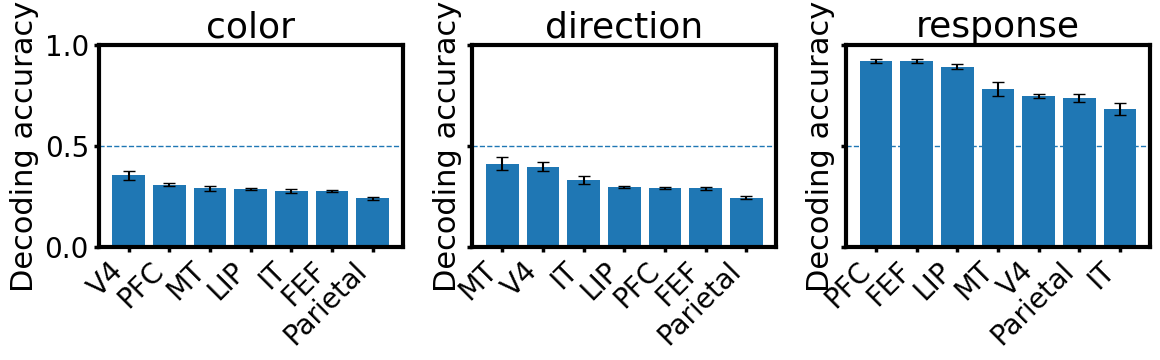

In [28]:
def plot_decoding_accuracy_bars(acc_summary):
    variables = acc_summary["variable"].unique()
    areas = acc_summary["area"].unique()

    n_vars = len(variables)
    fig, axes = plt.subplots(1, n_vars, figsize=(4*n_vars, 4), sharey=True)

    if n_vars == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        sub = acc_summary[acc_summary["variable"] == var]

        x = np.arange(len(sub))
        ax.bar(
            x,
            sub["mean_acc"],
            yerr=sub["sem_acc"],
            capsize=4
        )

        ax.set_xticks(x)
        ax.set_xticklabels(sub["area"], rotation=45, ha="right")
        ax.set_title(var)
        ax.set_ylabel("Decoding accuracy")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()

plot_decoding_accuracy_bars(acc_summary)


In [32]:
# =========================
# Cross-validated GLM R²
# =========================

def _best_n_splits_for_stratified_cv(y: np.ndarray, desired: int) -> int:
    """
    Return the largest valid n_splits ≤ desired given class counts in y.
    Need at least 2 splits and at least n_splits samples in every class.
    """
    classes, counts = np.unique(y, return_counts=True)
    if classes.size < 2:
        return 0  # invalid for stratified CV
    max_splits = int(np.min(counts))
    return max(0, min(desired, max_splits))

def cross_validated_variance_glm(
    X: np.ndarray,
    y: np.ndarray,
    n_splits: int = 5,
    random_state: int = 0,
    C: float = 1.0,
    max_iter: int = 5000
) -> Tuple[float, np.ndarray, np.ndarray, int]:
    """
    Compute cross-validated explained variance (pseudo-R²) for logistic regression.
    Pseudo-R² defined via squared error on probabilities:
        R² = 1 - sum((y - p)^2) / sum((y - y_bar)^2)

    Returns: (r2, y_true_concat, y_pred_concat, n_splits_used)
    """
    y = np.asarray(y).ravel().astype(int)
    # ensure valid number of folds for stratified CV
    n_splits_used = _best_n_splits_for_stratified_cv(y, n_splits)
    if n_splits_used < 2:
        return np.nan, np.array([]), np.array([]), n_splits_used

    cv = StratifiedKFold(n_splits=n_splits_used, shuffle=True, random_state=random_state)

    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=max_iter,
            fit_intercept=False,  # you already include bias column
            random_state=random_state
        )
        model.fit(X_train, y_train)
        # probability of class 1
        y_pred = model.predict_proba(X_test)[:, 1]

        y_true_all.append(y_test)
        y_pred_all.append(y_pred)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    ss_res = np.sum((y_true_all - y_pred_all) ** 2)
    ss_tot = np.sum((y_true_all - np.mean(y_true_all)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

    return float(r2), y_true_all, y_pred_all, n_splits_used


# =========================
# Apply to your `results`
# =========================

def stack_variant_data_for_area(results: Dict, area: str, variant: str = "neural") -> Tuple[np.ndarray, np.ndarray]:
    """
    Stack all sessions' inpts and true_choices for a given area & variant.
    Returns X (N, M), y (N,)
    """
    bucket = results["areas"][area][variant]
    inpts_list = bucket["inpts"]
    y_list = bucket["true_choices"]
    if not inpts_list:
        return np.empty((0, 0)), np.array([])
    X = np.vstack(inpts_list)
    y = np.vstack(y_list).ravel().astype(int)
    return X, y

def compute_neural_cv_r2_all_areas(
    results: Dict,
    areas: List[str],
    n_splits: int = 1,
    random_state: int = 0,
    C: float = 1.0,
    max_iter: int = 5000,
) -> Dict[str, Dict[str, float]]:
    """
    For each area, compute cross-validated pseudo-R² for the NEURAL-only design.
    Returns a dict: area -> {"r2": ..., "n_splits_used": ..., "n_trials": ...}
    """
    out = {}
    for area in areas:
        X, y = stack_variant_data_for_area(results, area, variant="neural")
        if X.size == 0 or y.size == 0:
            out[area] = {"r2": np.nan, "n_splits_used": 0, "n_trials": 0}
            continue

        r2, y_true, y_pred, n_used = cross_validated_variance_glm(
            X, y, n_splits=n_splits, random_state=random_state, C=C, max_iter=max_iter
        )
        out[area] = {
            "r2": float(r2),
            "n_splits_used": int(n_used),
            "n_trials": int(len(y_true)) if n_used >= 2 else int(len(y)),
        }
    return out


# =========================
# Quick run + print table
# =========================

# Assuming you already executed:
# results = build_all_glmhmm_inputs(data_neural)
areas = list(results["areas"].keys())  # or use your AREA_LIST
neural_cv = compute_neural_cv_r2_all_areas(results, areas, n_splits=5, random_state=0)

print("=== Cross-validated pseudo-R² (Neural-only) by area ===")
for a in areas:
    info = neural_cv.get(a, {})
    print(f"{a:9s}  R² = {info.get('r2', np.nan):6.3f}   folds={info.get('n_splits_used', 0)}   N={info.get('n_trials', 0)}")


=== Cross-validated pseudo-R² (Neural-only) by area ===
FEF        R² =  0.019   folds=5   N=57501
PFC        R² =  0.015   folds=5   N=57501
LIP        R² =  0.014   folds=5   N=54698
Parietal   R² = -0.000   folds=5   N=29293
V4         R² =  0.013   folds=5   N=16384
MT         R² =  0.022   folds=5   N=13292
IT         R² =  0.001   folds=5   N=8931


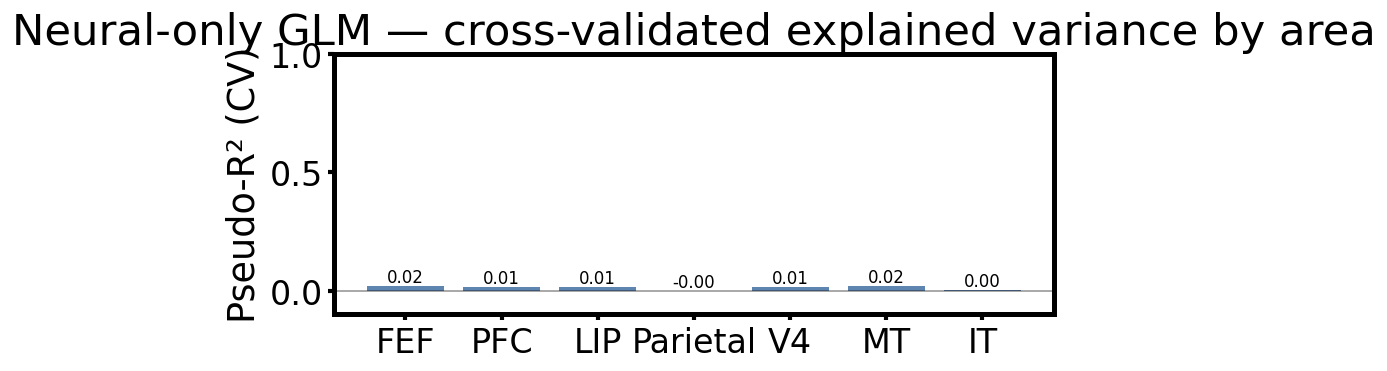

In [33]:
def plot_neural_cv_r2_bar(neural_cv: Dict[str, Dict[str, float]]):
    areas = list(neural_cv.keys())
    r2_vals = [neural_cv[a]["r2"] for a in areas]

    fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=120)
    bars = ax.bar(areas, r2_vals, color="#4C78A8", alpha=0.9)
    ax.axhline(0, color="k", lw=1, alpha=0.4)
    ax.set_ylabel("Pseudo-R² (CV)")
    ax.set_title("Neural-only GLM — cross-validated explained variance by area")
    ax.set_ylim(min(-0.1, min(r2_vals) if len(r2_vals) else -0.1), 1.0)
    for b, r in zip(bars, r2_vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{r:.2f}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_neural_cv_r2_bar(neural_cv)


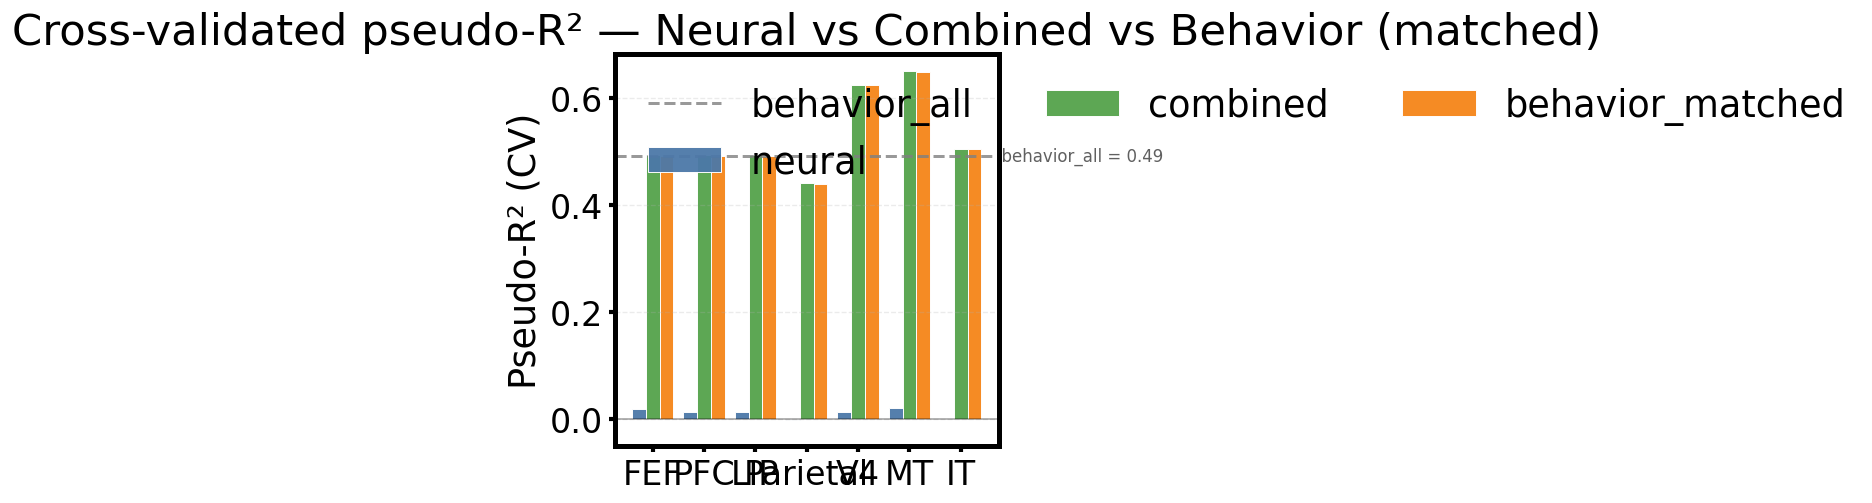

In [34]:
# =========================
# Cross-validated GLM R²
# =========================
# -------- helpers to ensure valid CV --------
def _best_n_splits_for_stratified_cv(y: np.ndarray, desired: int) -> int:
    """
    Return the largest valid n_splits ≤ desired given class counts in y.
    Need at least 2 splits and at least n_splits samples in every class.
    """
    y = np.asarray(y).ravel()
    classes, counts = np.unique(y, return_counts=True)
    if classes.size < 2:
        return 0  # invalid for stratified CV
    max_splits = int(np.min(counts))
    return max(0, min(desired, max_splits))

def cross_validated_variance_glm(
    X: np.ndarray,
    y: np.ndarray,
    n_splits: int = 5,
    random_state: int = 0,
    C: float = 1.0,
    max_iter: int = 5000
) -> Tuple[float, int]:
    """
    Cross-validated explained variance (pseudo-R²) for logistic regression.
    Pseudo-R² via squared error on predicted probabilities:
        R² = 1 - sum((y - p)^2) / sum((y - y_bar)^2)

    Returns (r2, n_splits_used). Returns (nan, 0) if CV not possible.
    """
    if X.size == 0 or y.size == 0:
        return np.nan, 0

    y = np.asarray(y).ravel().astype(int)
    n_splits_used = _best_n_splits_for_stratified_cv(y, n_splits)
    if n_splits_used < 2:
        return np.nan, n_splits_used

    cv = StratifiedKFold(n_splits=n_splits_used, shuffle=True, random_state=random_state)
    y_true_all, y_pred_all = [], []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=max_iter,
            fit_intercept=False,  # bias already included in your X
            random_state=random_state
        )
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        y_true_all.append(y_test)
        y_pred_all.append(y_pred)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    ss_res = np.sum((y_true_all - y_pred_all) ** 2)
    ss_tot = np.sum((y_true_all - np.mean(y_true_all)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(r2), n_splits_used

# -------- stack data from your results --------
def _stack_variant_area(results: Dict, area: str, variant: str) -> Tuple[np.ndarray, np.ndarray]:
    """Stack all sessions’ X and y for a given area & variant."""
    bucket = results["areas"][area][variant]
    inpts_list = bucket["inpts"]
    y_list = bucket["true_choices"]
    if not inpts_list:
        return np.empty((0, 0)), np.array([])
    X = np.vstack(inpts_list)
    y = np.vstack(y_list).ravel().astype(int)
    return X, y

def _stack_behavior_all(results: Dict) -> Tuple[np.ndarray, np.ndarray]:
    """Stack all sessions’ X and y for global behavior_all."""
    bucket = results["behavior_all"]
    inpts_list = bucket["inpts"]
    y_list = bucket["true_choices"]
    if not inpts_list:
        return np.empty((0, 0)), np.array([])
    X = np.vstack(inpts_list)
    y = np.vstack(y_list).ravel().astype(int)
    return X, y

# -------- compute CV R² for all variants you asked --------
def compute_cv_r2_all_variants(
    results: Dict,
    areas: List[str],
    n_splits: int = 1,
    random_state: int = 0,
    C: float = 1.0,
    max_iter: int = 5000
) -> Tuple[Dict[str, Dict[str, float]], float]:
    """
    Returns:
      per_area: { area: {"neural": r2, "combined": r2, "behavior_matched": r2} }
      behavior_all_r2: float
    """
    per_area: Dict[str, Dict[str, float]] = {}

    # global behavior_all baseline
    Xb, yb = _stack_behavior_all(results)
    behavior_all_r2, _ = cross_validated_variance_glm(
        Xb, yb, n_splits=n_splits, random_state=random_state, C=C, max_iter=max_iter
    )

    for area in areas:
        area_dict = {}
        # neural
        Xn, yn = _stack_variant_area(results, area, "neural")
        r2_neural, _ = cross_validated_variance_glm(
            Xn, yn, n_splits=n_splits, random_state=random_state, C=C, max_iter=max_iter
        )
        area_dict["neural"] = r2_neural

        # combined
        Xc, yc = _stack_variant_area(results, area, "combined")
        r2_combined, _ = cross_validated_variance_glm(
            Xc, yc, n_splits=n_splits, random_state=random_state, C=C, max_iter=max_iter
        )
        area_dict["combined"] = r2_combined

        # behavior_matched
        Xbm, ybm = _stack_variant_area(results, area, "behavior_matched")
        r2_beh_match, _ = cross_validated_variance_glm(
            Xbm, ybm, n_splits=n_splits, random_state=random_state, C=C, max_iter=max_iter
        )
        area_dict["behavior_matched"] = r2_beh_match

        per_area[area] = area_dict

    return per_area, behavior_all_r2

# -------- grouped bar plot --------
def plot_cv_r2_grouped_by_area(
    per_area: Dict[str, Dict[str, float]],
    behavior_all_r2: float,
    area_order: List[str] = None,
    title: str = "Cross-validated pseudo-R² by area"
):
    """
    X-axis = areas. Inside each area: 3 bars — neural, combined, behavior_matched.
    Adds a horizontal grey line for behavior_all baseline.
    """
    # order areas
    areas = area_order if area_order is not None else list(per_area.keys())

    # gather values (use nan-safe)
    neural_vals   = [per_area.get(a, {}).get("neural", np.nan) for a in areas]
    combined_vals = [per_area.get(a, {}).get("combined", np.nan) for a in areas]
    behm_vals     = [per_area.get(a, {}).get("behavior_matched", np.nan) for a in areas]

    x = np.arange(len(areas))
    n_groups = 3
    width = 0.8 / n_groups
    offsets = [-width, 0.0, width]  # neural, combined, behavior_matched

    colors = {
        "neural": "#4C78A8",
        "combined": "#54A24B",
        "behavior_matched": "#F58518"
    }

    fig, ax = plt.subplots(figsize=(max(8.5, 1.1 * len(areas)), 4.6), dpi=120)

    # plot bars with NaN handling
    series = [
        ("neural", neural_vals, offsets[0], colors["neural"]),
        ("combined", combined_vals, offsets[1], colors["combined"]),
        ("behavior_matched", behm_vals, offsets[2], colors["behavior_matched"]),
    ]

    for label, vals, off, col in series:
        vals_arr = np.array(vals, dtype=float)
        bars = ax.bar(x + off, np.nan_to_num(vals_arr, nan=0.0), width=width, label=label,
                      color=col, alpha=0.95, edgecolor="white", linewidth=0.6)
        # annotate NaNs
        for xi, v, b in zip(x + off, vals_arr, bars):
            if np.isnan(v):
                ax.text(b.get_x() + b.get_width()/2, 0.01, "NA", ha="center", va="bottom", fontsize=9, rotation=90)

    # horizontal baseline for behavior_all
    if np.isfinite(behavior_all_r2):
        ax.axhline(behavior_all_r2, color="#808080", lw=1.8, alpha=0.8, ls="--", label="behavior_all")
        ax.text(x[-1] + 0.6, behavior_all_r2, f"  behavior_all = {behavior_all_r2:.2f}",
                va="center", ha="left", color="#606060", fontsize=10)

    ax.axhline(0, color="k", lw=1, alpha=0.35)
    ax.set_xticks(x)
    ax.set_xticklabels(areas, rotation=0)
    ax.set_ylabel("Pseudo-R² (CV)")
    ax.set_title(title)
    ax.set_ylim(bottom=min(-0.05, np.nanmin(neural_vals + combined_vals + behm_vals + [behavior_all_r2]) - 0.05 if len(areas) else -0.1))
    ax.legend(frameon=False, ncol=3, loc="upper left")
    ax.grid(True, axis="y", linestyle="--", alpha=0.25)
    plt.tight_layout()
    plt.show()

# =========================
# Example usage
# =========================
# Assuming you already have:
# results = build_all_glmhmm_inputs(data_neural)

AREA_LIST = ['FEF', 'PFC', 'LIP', 'Parietal', 'V4', 'MT', 'IT']
areas_present = [a for a in AREA_LIST if a in results["areas"]]

per_area, beh_all_r2 = compute_cv_r2_all_variants(
    results, areas_present, n_splits=5, random_state=0, C=1.0, max_iter=5000
)

plot_cv_r2_grouped_by_area(
    per_area, beh_all_r2, area_order=areas_present,
    title="Cross-validated pseudo-R² — Neural vs Combined vs Behavior (matched)"
)


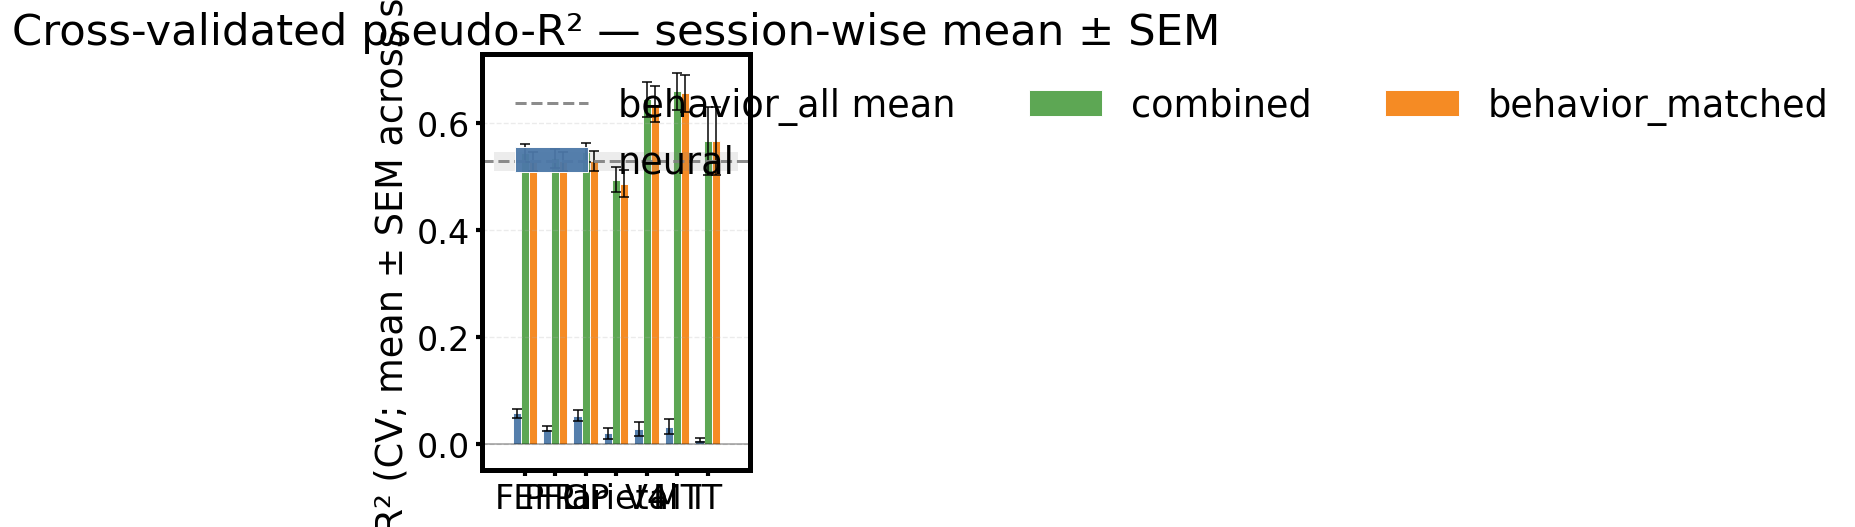

In [35]:
### session level

import numpy as np
from typing import Dict, Tuple, List

def _r2_per_session(
    inpts_list: List[np.ndarray],
    y_list: List[np.ndarray],
    n_splits: int = 5,
    random_state: int = 0,
    C: float = 1.0,
    max_iter: int = 5000
) -> np.ndarray:
    """
    Compute cross-validated pseudo-R² for each session separately.
    Returns an array of shape (n_sessions,) with NaNs for sessions
    where stratified CV is not possible.
    """
    r2_vals = []
    for X_sess, y_sess in zip(inpts_list, y_list):
        r2, _ = cross_validated_variance_glm(
            X_sess, y_sess,
            n_splits=n_splits,
            random_state=random_state,
            C=C,
            max_iter=max_iter,
        )
        r2_vals.append(r2)
    return np.array(r2_vals, dtype=float)


def _mean_sem(x: np.ndarray) -> Tuple[float, float]:
    """
    Mean and SEM ignoring NaNs.
    """
    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    if not np.any(finite):
        return np.nan, np.nan
    x_f = x[finite]
    mean = float(np.mean(x_f))
    if x_f.size > 1:
        sem = float(np.std(x_f, ddof=1) / np.sqrt(x_f.size))
    else:
        sem = np.nan
    return mean, sem

def compute_cv_r2_all_variants_sessionwise(
    results: Dict,
    areas: List[str],
    n_splits: int = 5,
    random_state: int = 0,
    C: float = 1.0,
    max_iter: int = 5000
) -> Tuple[Dict[str, Dict[str, Dict[str, np.ndarray]]], Dict[str, np.ndarray]]:
    """
    Returns:
      per_area_stats: {
        area: {
          "neural": {
              "per_session": np.ndarray,
              "mean": float,
              "sem": float
          },
          "combined": {...},
          "behavior_matched": {...}
        }, ...
      }

      behavior_all_stats: {
        "per_session": np.ndarray,
        "mean": float,
        "sem": float
      }

    Assumes:
      - results["areas"][area][variant]["inpts"] is a list of (T_sess x p) arrays
      - results["areas"][area][variant]["true_choices"] is a list of (T_sess,) arrays
      - results["behavior_all"]["inpts"], ["true_choices"] are also per-session lists.
    """
    per_area_stats: Dict[str, Dict[str, Dict[str, np.ndarray]]] = {}

    # ---- behavior_all baseline, session-wise ----
    beh_bucket = results["behavior_all"]
    beh_inpts_list = beh_bucket["inpts"]
    beh_y_list = beh_bucket["true_choices"]

    beh_r2_per_session = _r2_per_session(
        beh_inpts_list, beh_y_list,
        n_splits=n_splits,
        random_state=random_state,
        C=C,
        max_iter=max_iter,
    )
    beh_mean, beh_sem = _mean_sem(beh_r2_per_session)
    behavior_all_stats = {
        "per_session": beh_r2_per_session,
        "mean": beh_mean,
        "sem": beh_sem
    }

    # ---- per area / variant ----
    for area in areas:
        area_stats: Dict[str, Dict[str, np.ndarray]] = {}
        for variant in ["neural", "combined", "behavior_matched"]:
            bucket = results["areas"][area][variant]
            inpts_list = bucket["inpts"]
            y_list = bucket["true_choices"]

            r2_per_session = _r2_per_session(
                inpts_list, y_list,
                n_splits=n_splits,
                random_state=random_state,
                C=C,
                max_iter=max_iter,
            )
            mean, sem = _mean_sem(r2_per_session)
            area_stats[variant] = {
                "per_session": r2_per_session,
                "mean": mean,
                "sem": sem
            }
        per_area_stats[area] = area_stats

    return per_area_stats, behavior_all_stats


import matplotlib.pyplot as plt

def plot_cv_r2_grouped_by_area_sessionwise(
    per_area_stats: Dict[str, Dict[str, Dict[str, np.ndarray]]],
    behavior_all_stats: Dict[str, np.ndarray],
    area_order: List[str] = None,
    title: str = "Cross-validated pseudo-R² by area (session-wise mean ± SEM)"
):
    """
    X-axis = areas. Inside each area: 3 bars — neural, combined, behavior_matched.
    Each bar has SEM error bar across sessions.
    Adds a horizontal line (± SEM band) for behavior_all baseline.
    """
    areas = area_order if area_order is not None else list(per_area_stats.keys())

    neural_means   = [per_area_stats[a]["neural"]["mean"] for a in areas]
    combined_means = [per_area_stats[a]["combined"]["mean"] for a in areas]
    behm_means     = [per_area_stats[a]["behavior_matched"]["mean"] for a in areas]

    neural_sems   = [per_area_stats[a]["neural"]["sem"] for a in areas]
    combined_sems = [per_area_stats[a]["combined"]["sem"] for a in areas]
    behm_sems     = [per_area_stats[a]["behavior_matched"]["sem"] for a in areas]

    x = np.arange(len(areas))
    n_groups = 3
    width = 0.8 / n_groups
    offsets = [-width, 0.0, width]

    colors = {
        "neural": "#4C78A8",
        "combined": "#54A24B",
        "behavior_matched": "#F58518"
    }

    fig, ax = plt.subplots(figsize=(max(8.5, 1.1 * len(areas)), 4.8), dpi=120)

    series = [
        ("neural", neural_means, neural_sems, offsets[0], colors["neural"]),
        ("combined", combined_means, combined_sems, offsets[1], colors["combined"]),
        ("behavior_matched", behm_means, behm_sems, offsets[2], colors["behavior_matched"]),
    ]

    for label, means, sems, off, col in series:
        means_arr = np.array(means, dtype=float)
        sems_arr = np.array(sems, dtype=float)
        bars = ax.bar(
            x + off,
            np.nan_to_num(means_arr, nan=0.0),
            width=width,
            label=label,
            color=col,
            alpha=0.95,
            edgecolor="white",
            linewidth=0.6
        )
        # error bars (ignoring NaNs)
        for i, (m, s, b) in enumerate(zip(means_arr, sems_arr, bars)):
            if np.isfinite(m) and np.isfinite(s):
                ax.errorbar(
                    b.get_x() + b.get_width() / 2,
                    m,
                    yerr=s,
                    fmt="none",
                    ecolor="black",
                    elinewidth=1,
                    capsize=3,
                    alpha=0.9
                )
            elif np.isnan(m):
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    0.01,
                    "NA",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    rotation=90
                )

    # behavior_all baseline with SEM band
    beh_mean = behavior_all_stats["mean"]
    beh_sem = behavior_all_stats["sem"]

    if np.isfinite(beh_mean):
        ax.axhline(beh_mean, color="#808080", lw=1.8, alpha=0.9, ls="--", label="behavior_all mean")
        if np.isfinite(beh_sem):
            ax.fill_between(
                [x[0] - 1, x[-1] + 1],
                beh_mean - beh_sem,
                beh_mean + beh_sem,
                color="#808080",
                alpha=0.15,
                linewidth=0
            )

    all_vals = np.concatenate([
        np.array(neural_means),
        np.array(combined_means),
        np.array(behm_means),
        np.array([beh_mean])
    ])
    finite_vals = all_vals[np.isfinite(all_vals)]
    ymin = min(-0.05, np.min(finite_vals) - 0.05) if finite_vals.size else -0.1

    ax.axhline(0, color="k", lw=1, alpha=0.35)
    ax.set_xticks(x)
    ax.set_xticklabels(areas, rotation=0)
    ax.set_ylabel("Pseudo-R² (CV; mean ± SEM across sessions)")
    ax.set_title(title)
    ax.set_ylim(bottom=ymin)
    ax.legend(frameon=False, ncol=3, loc="upper left")
    ax.grid(True, axis="y", linestyle="--", alpha=0.25)
    plt.tight_layout()
    plt.show()


AREA_LIST = ['FEF', 'PFC', 'LIP', 'Parietal', 'V4', 'MT', 'IT']
areas_present = [a for a in AREA_LIST if a in results["areas"]]

per_area_stats, behavior_all_stats = compute_cv_r2_all_variants_sessionwise(
    results,
    areas_present,
    n_splits=5,
    random_state=0,
    C=1.0,
    max_iter=5000
)

plot_cv_r2_grouped_by_area_sessionwise(
    per_area_stats,
    behavior_all_stats,
    area_order=areas_present,
    title="Cross-validated pseudo-R² — session-wise mean ± SEM"
)


C:\Users\shahe\AppData\Local\Temp\ipykernel_22576\616020358.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


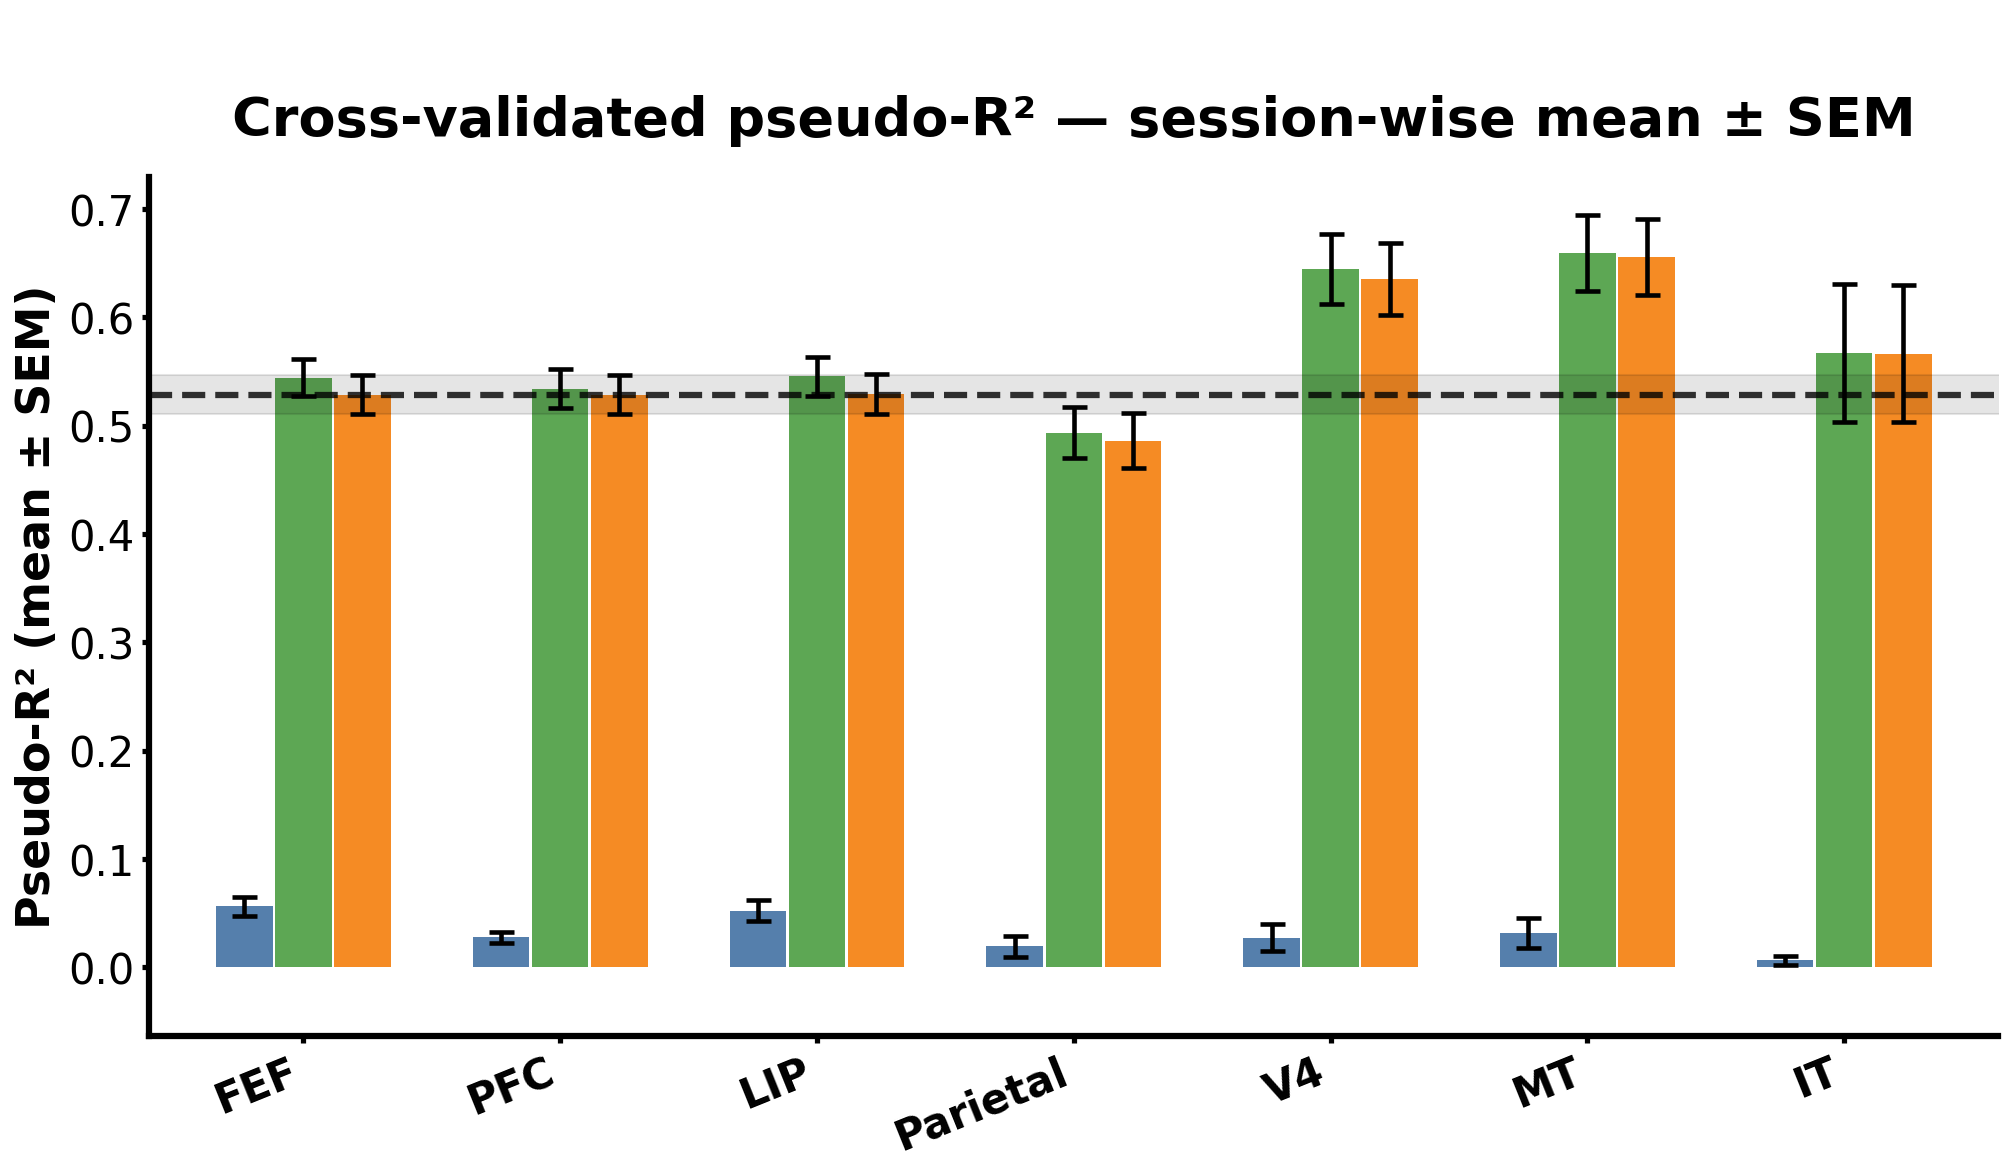

In [36]:
def plot_cv_r2_grouped_by_area_sessionwise_poster(
    per_area_stats: Dict[str, Dict[str, Dict[str, np.ndarray]]],
    behavior_all_stats: Dict[str, np.ndarray],
    area_order: List[str] = None,
    title: str = "Cross-validated pseudo-R² — session-wise mean ± SEM"
):
    """
    Poster-ready grouped-bar plot: clean, non-overlapping, spacious.
    """
    plt.style.use("default")

    # === FONT & STYLE ===
    plt.rcParams.update({
        "font.size": 20,
        "axes.titlesize": 26,
        "axes.labelsize": 22,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 22,
        "axes.linewidth": 3,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    })

    areas = area_order if area_order is not None else list(per_area_stats.keys())
    N = len(areas)
    x = np.arange(N)

    # === Extract means & SEMs ===
    neural_means   = np.array([per_area_stats[a]["neural"]["mean"] for a in areas])
    combined_means = np.array([per_area_stats[a]["combined"]["mean"] for a in areas])
    behm_means     = np.array([per_area_stats[a]["behavior_matched"]["mean"] for a in areas])

    neural_sems   = np.array([per_area_stats[a]["neural"]["sem"] for a in areas])
    combined_sems = np.array([per_area_stats[a]["combined"]["sem"] for a in areas])
    behm_sems     = np.array([per_area_stats[a]["behavior_matched"]["sem"] for a in areas])

    # === Bar width and spacing (no overlap!) ===
    bar_width = 0.22
    group_offset = 0.23   # spacing between categories inside each area

    offsets = np.array([-group_offset, 0, group_offset])

    # === Larger, breathable figure ===
    fig_width = max(14, 1.7 * N)
    fig_height = 8.5
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=150)

    colors = {
        "neural": "#4C78A8",
        "combined": "#54A24B",
        "behavior_matched": "#F58518"
    }

    series = [
        ("Neural", neural_means, neural_sems, offsets[0], colors["neural"]),
        ("Combined", combined_means, combined_sems, offsets[1], colors["combined"]),
        ("Behavior matched", behm_means, behm_sems, offsets[2], colors["behavior_matched"]),
    ]

    # === Bars ===
    for label, means, sem, off, col in series:
        bars = ax.bar(
            x + off,
            np.nan_to_num(means),
            width=bar_width,
            color=col,
            edgecolor=None,   # ← no black border
            alpha=0.95
        )

        # Error bars
        for b, m, s in zip(bars, means, sem):
            if np.isfinite(m):
                ax.errorbar(
                    b.get_x() + b.get_width() / 2,
                    m,
                    yerr=s,
                    fmt="none",
                    ecolor="black",
                    elinewidth=2.2,
                    capsize=6,
                    capthick=2.2
                )

    # === Behavior baseline ===
    beh_mean = behavior_all_stats["mean"]
    beh_sem = behavior_all_stats["sem"]

    if np.isfinite(beh_mean):
        ax.axhline(beh_mean, color="black", lw=3, ls="--", alpha=0.8)
        if np.isfinite(beh_sem):
            ax.fill_between(
                [x[0] - 0.7, x[-1] + 0.7],
                beh_mean - beh_sem,
                beh_mean + beh_sem,
                color="black",
                alpha=0.10
            )

    # === Aesthetics ===
    ax.set_xticks(x)
    ax.set_xticklabels(areas, rotation=22, ha="right", fontweight="bold")
    ax.set_ylabel("Pseudo-R² (mean ± SEM)", fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=20)

    # Clean axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # === Y limits ===
    all_vals = np.concatenate([neural_means, combined_means, behm_means, [beh_mean]])
    finite_vals = all_vals[np.isfinite(all_vals)]
    ymin = min(-0.05, np.min(finite_vals) - 0.07)
    ymax = max(0.05, np.max(finite_vals) + 0.07)
    ax.set_ylim([ymin, ymax])

    # Clean left/right spacing
    ax.set_xlim([-0.6, N - 0.4])

    # Legend OUTSIDE plot
    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=3,
        frameon=False
    )

    plt.tight_layout(pad=1.4)
    plt.show()



plot_cv_r2_grouped_by_area_sessionwise_poster(
    per_area_stats,
    behavior_all_stats,
    area_order=areas_present,
    title="Cross-validated pseudo-R² — session-wise mean ± SEM"
)

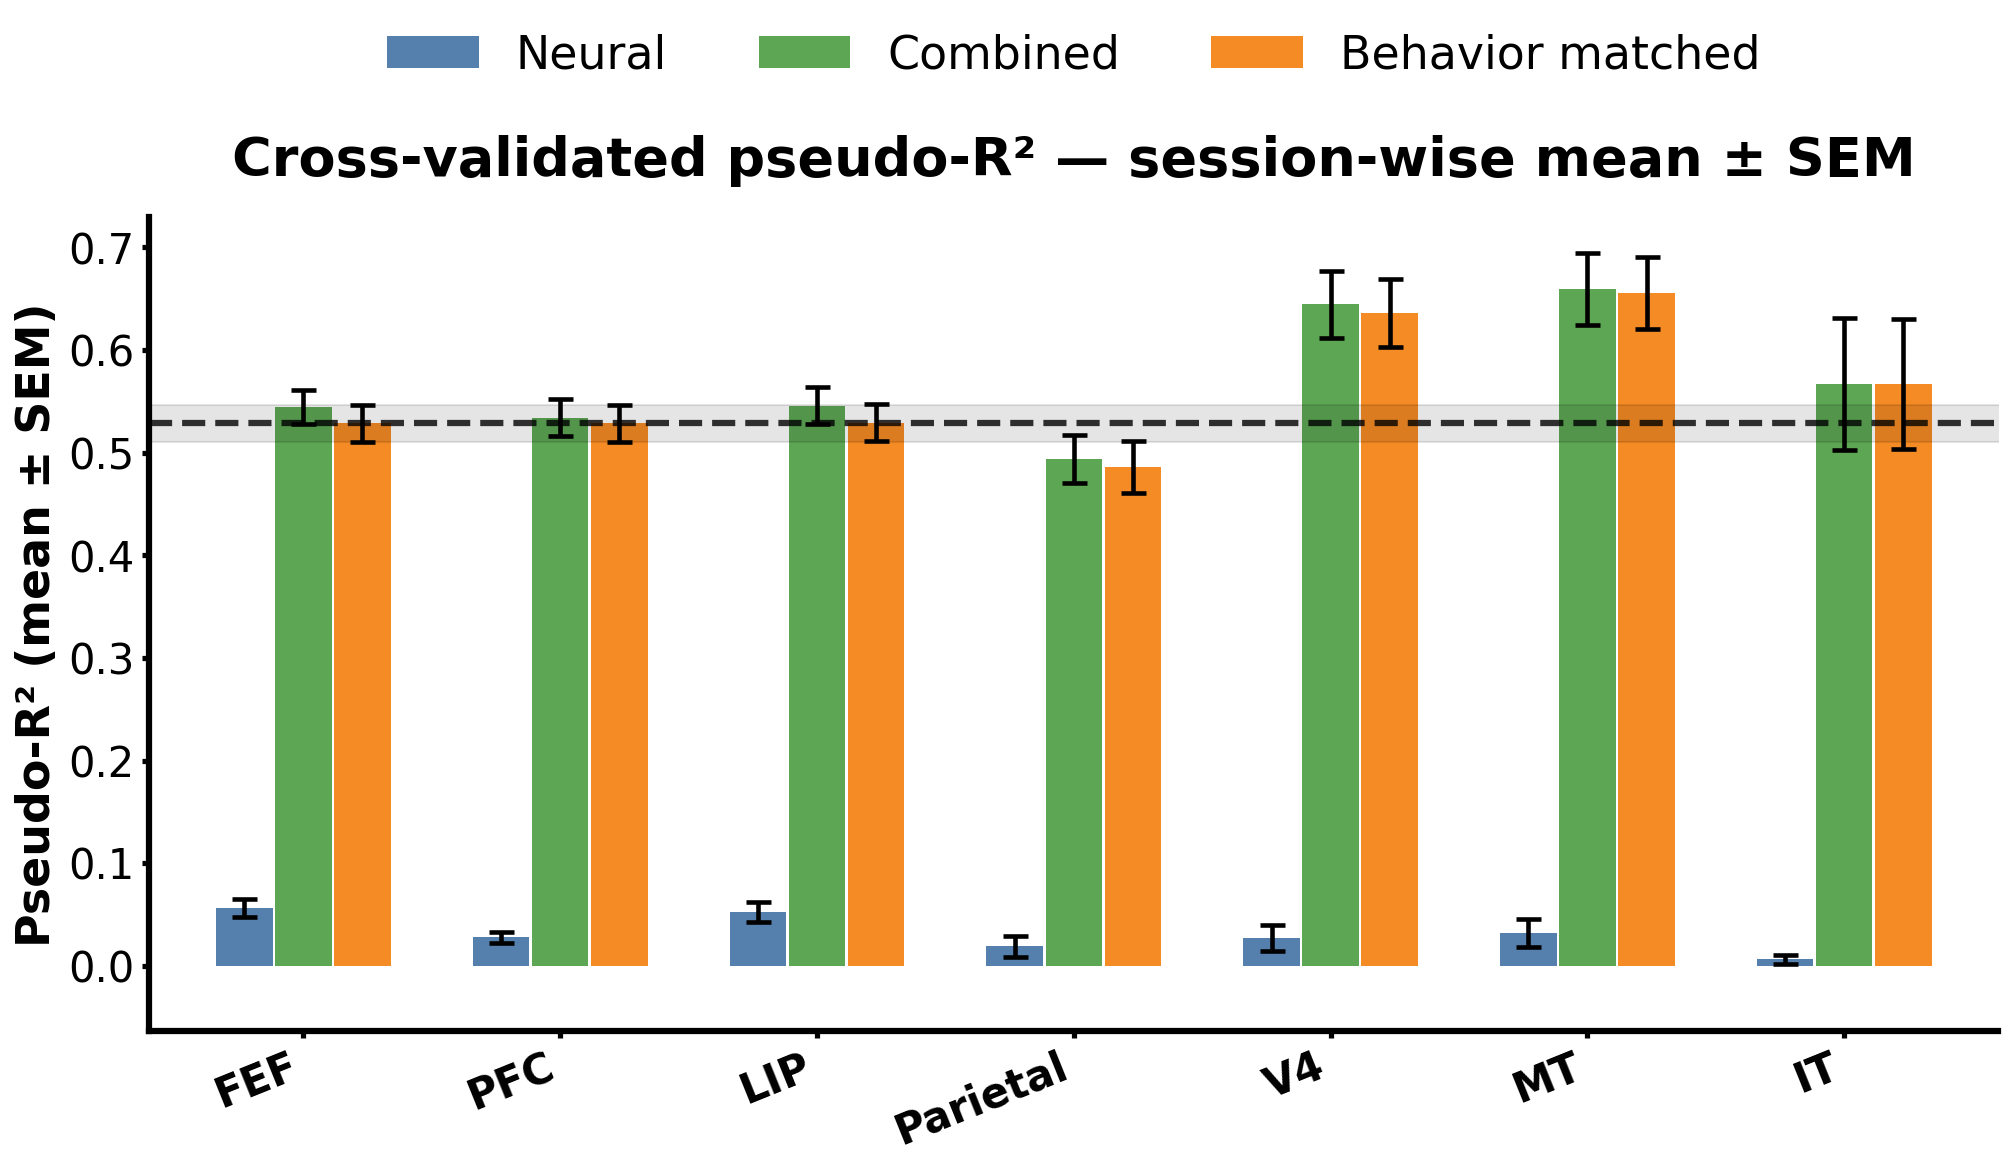

(<Figure size 2100x1275 with 1 Axes>,
 <Axes: title={'center': 'Cross-validated pseudo-R² — session-wise mean ± SEM'}, ylabel='Pseudo-R² (mean ± SEM)'>)

In [37]:

# Keep text editable in Illustrator / Inkscape
plt.rcParams["pdf.fonttype"] = 42   # TrueType fonts


def plot_cv_r2_grouped_by_area_sessionwise_poster(
    per_area_stats,
    behavior_all_stats,
    area_order=None,
    title="Cross-validated pseudo-R² — session-wise mean ± SEM",
    save_pdf_path=None,
    show=True,
):
    """
    Poster-ready grouped-bar plot: clean, non-overlapping, spacious.
    """

    plt.style.use("default")

    plt.rcParams.update({
        "font.size": 20,
        "axes.titlesize": 26,
        "axes.labelsize": 22,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 22,
        "axes.linewidth": 3,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    })

    areas = area_order if area_order is not None else list(per_area_stats.keys())
    N = len(areas)
    x = np.arange(N)

    # ---- Extract stats ----
    neural_means   = np.array([per_area_stats[a]["neural"]["mean"] for a in areas])
    combined_means = np.array([per_area_stats[a]["combined"]["mean"] for a in areas])
    behm_means     = np.array([per_area_stats[a]["behavior_matched"]["mean"] for a in areas])

    neural_sems   = np.array([per_area_stats[a]["neural"]["sem"] for a in areas])
    combined_sems = np.array([per_area_stats[a]["combined"]["sem"] for a in areas])
    behm_sems     = np.array([per_area_stats[a]["behavior_matched"]["sem"] for a in areas])

    # ---- Layout ----
    bar_width = 0.22
    group_offset = 0.23
    offsets = np.array([-group_offset, 0, group_offset])

    fig_width = max(14, 1.7 * N)
    fig_height = 8.5
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=150)

    colors = {
        "neural": "#4C78A8",
        "combined": "#54A24B",
        "behavior_matched": "#F58518"
    }

    series = [
        ("Neural", neural_means, neural_sems, offsets[0], colors["neural"]),
        ("Combined", combined_means, combined_sems, offsets[1], colors["combined"]),
        ("Behavior matched", behm_means, behm_sems, offsets[2], colors["behavior_matched"]),
    ]

    # ---- Bars + error bars ----
    for label, means, sem, off, col in series:
        bars = ax.bar(
            x + off,
            np.nan_to_num(means),
            width=bar_width,
            color=col,
            edgecolor=None,
            alpha=0.95,
            label=label
        )

        for b, m, s in zip(bars, means, sem):
            if np.isfinite(m):
                ax.errorbar(
                    b.get_x() + b.get_width() / 2,
                    m,
                    yerr=s,
                    fmt="none",
                    ecolor="black",
                    elinewidth=2.2,
                    capsize=6,
                    capthick=2.2
                )

    # ---- Behavior baseline ----
    beh_mean = behavior_all_stats["mean"]
    beh_sem = behavior_all_stats["sem"]

    if np.isfinite(beh_mean):
        ax.axhline(beh_mean, color="black", lw=3, ls="--", alpha=0.8)
        if np.isfinite(beh_sem):
            ax.fill_between(
                [x[0] - 0.7, x[-1] + 0.7],
                beh_mean - beh_sem,
                beh_mean + beh_sem,
                color="black",
                alpha=0.10
            )

    # ---- Labels & styling ----
    ax.set_xticks(x)
    ax.set_xticklabels(areas, rotation=22, ha="right", fontweight="bold")
    ax.set_ylabel("Pseudo-R² (mean ± SEM)", fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    all_vals = np.concatenate([neural_means, combined_means, behm_means, [beh_mean]])
    finite_vals = all_vals[np.isfinite(all_vals)]
    ymin = min(-0.05, np.min(finite_vals) - 0.07)
    ymax = max(0.05, np.max(finite_vals) + 0.07)
    ax.set_ylim([ymin, ymax])

    ax.set_xlim([-0.6, N - 0.4])

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=3,
        frameon=False
    )

    plt.tight_layout(pad=1.4)

    # ---- SAVE AS PDF ----
    if save_pdf_path is not None:
        os.makedirs(os.path.dirname(save_pdf_path) or ".", exist_ok=True)
        fig.savefig(save_pdf_path, format="pdf", bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax
plot_cv_r2_grouped_by_area_sessionwise_poster(
    per_area_stats,
    behavior_all_stats,
    area_order=areas_present,
    title="Cross-validated pseudo-R² — session-wise mean ± SEM",
    save_pdf_path="cv_pseudoR2_by_area.pdf",
)


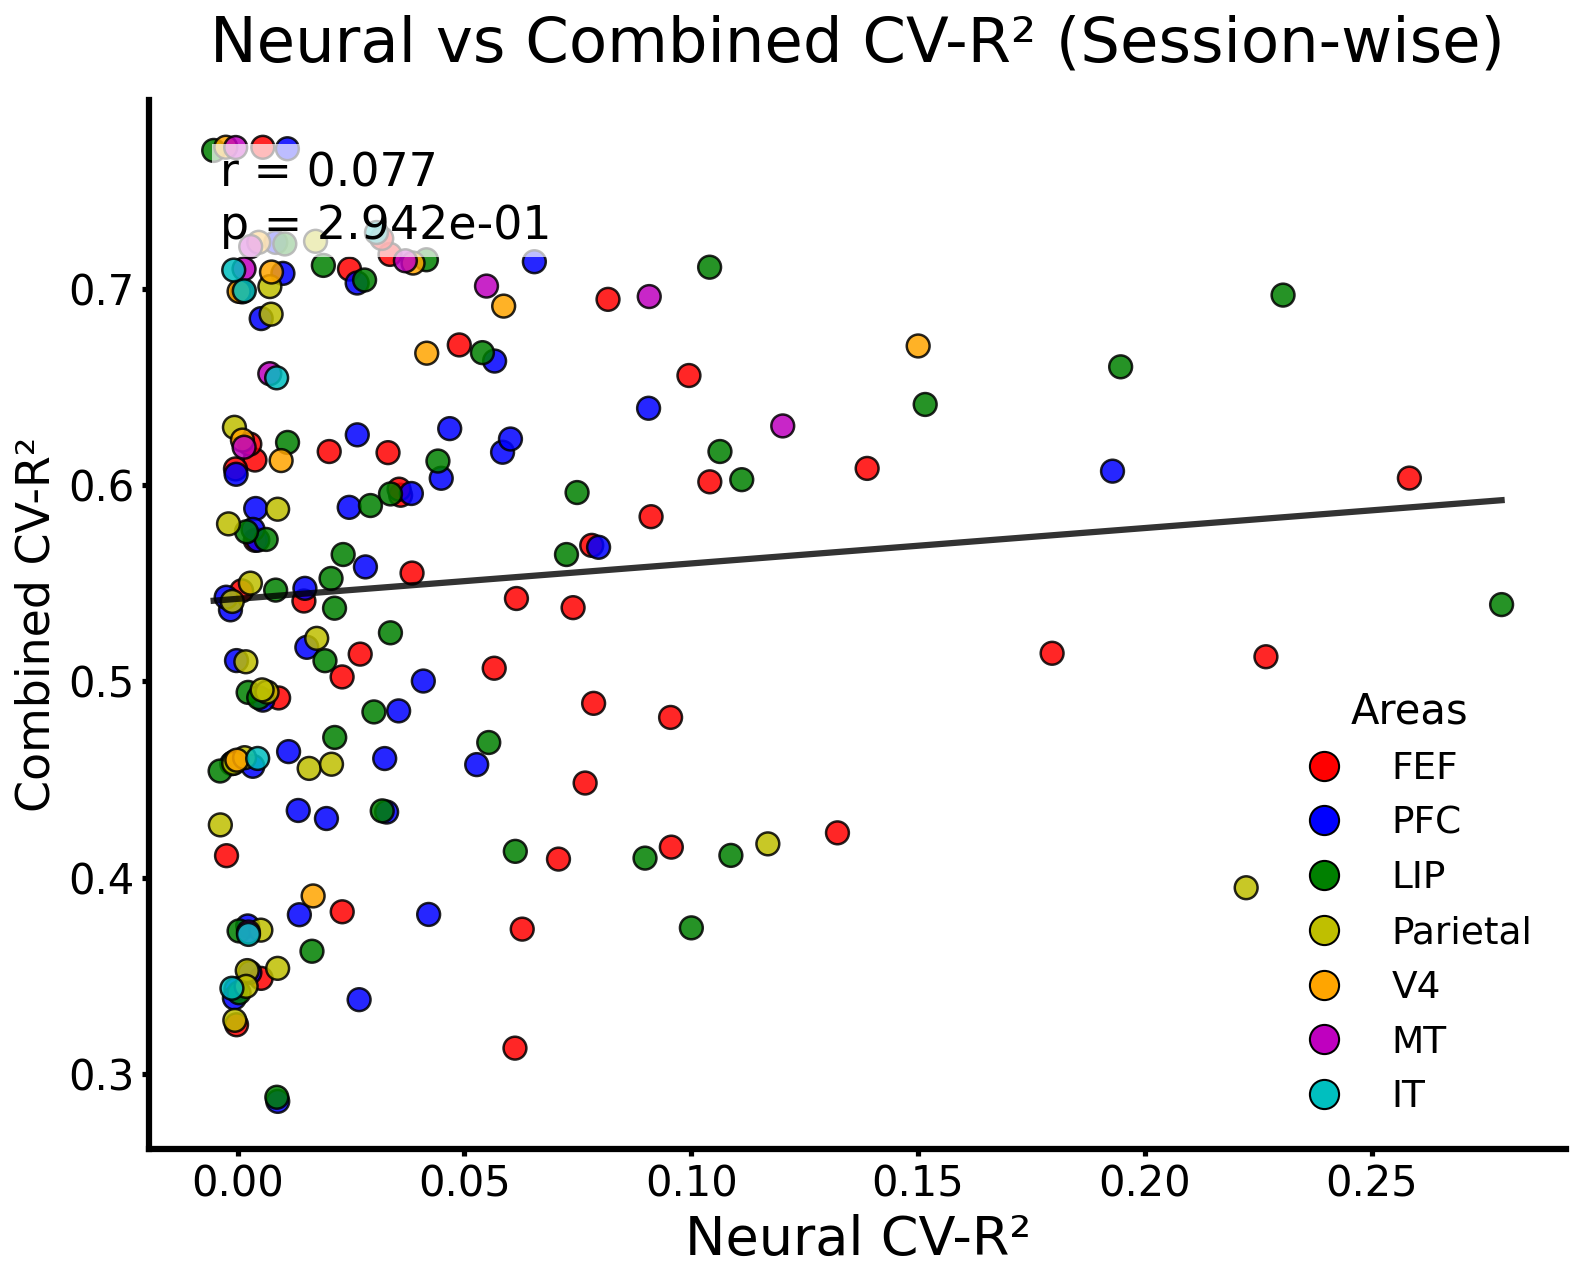

In [39]:

def plot_neural_vs_combined_cv_scatter(
    per_area_stats,
    areas,
    title="Neural vs Combined CV-R² (session-wise)"
):
    """
    Scatterplot of neural CV-R² vs combined CV-R².
    Each point = one session, color-coded by area.
    Computes Pearson correlation across *all* sessions.
    """

    # --- Colors per area ---
    area_colors = {
        'PFC': 'b',
        'FEF': 'r',
        'LIP': 'g',
        'Parietal': 'y',
        'IT': 'c',
        'MT': 'm',
        'V4': 'orange'
    }

    # --- Collect points from all areas ---
    x_vals = []  # neural
    y_vals = []  # combined
    color_list = []
    label_list = []

    for area in areas:
        neural_sess = np.asarray(per_area_stats[area]["neural"]["per_session"], float)
        combined_sess = np.asarray(per_area_stats[area]["combined"]["per_session"], float)

        # remove NaNs
        mask = np.isfinite(neural_sess) & np.isfinite(combined_sess)
        neural_sess = neural_sess[mask]
        combined_sess = combined_sess[mask]

        x_vals.append(neural_sess)
        y_vals.append(combined_sess)
        color_list.extend([area_colors.get(area, "gray")] * len(neural_sess))
        label_list.extend([area] * len(neural_sess))

    x_vals = np.concatenate(x_vals)
    y_vals = np.concatenate(y_vals)

    # --- Compute correlation ---
    if len(x_vals) > 1:
        r, p = pearsonr(x_vals, y_vals)
    else:
        r, p = np.nan, np.nan

    # --- Plot ---
    plt.style.use("default")
    plt.rcParams.update({
        "font.size": 22,
        "axes.labelsize": 26,
        "axes.titlesize": 30,
        "axes.linewidth": 3,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
    })

    fig, ax = plt.subplots(figsize=(11, 9), dpi=150)

    # --- Scatter points ---
    sc = ax.scatter(
        x_vals, y_vals,
        c=color_list,
        s=120,
        alpha=0.85,
        edgecolor="black",
        linewidth=1.2
    )

    # --- Regression line ---
    if len(x_vals) > 1:
        coeff = np.polyfit(x_vals, y_vals, 1)
        xs = np.linspace(min(x_vals), max(x_vals), 200)
        ys = coeff[0] * xs + coeff[1]
        ax.plot(xs, ys, color="black", lw=3, alpha=0.8)

    # --- Labels ---
    ax.set_xlabel("Neural CV-R²")
    ax.set_ylabel("Combined CV-R²", fontsize=22)
    ax.set_title(title, pad=18)

    # --- Pearson text annotation ---
    ax.text(
        0.05, 0.95,
        f"r = {r:.3f}\np = {p:.3e}",
        transform=ax.transAxes,
        fontsize=22,
        ha="left",
        va="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    # --- Legend ---
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='none',
                   markerfacecolor=area_colors.get(area, "gray"),
                   markeredgecolor="black", markersize=14)
        for area in areas
    ]
    ax.legend(
        legend_handles,
        areas,
        title="Areas",
        frameon=False,
        loc="lower right",
        fontsize=18,
        title_fontsize=20
    )

    # --- Clean axes ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_neural_vs_combined_cv_scatter(
    per_area_stats,
    areas_present,
    title="Neural vs Combined CV-R² (Session-wise)"
)


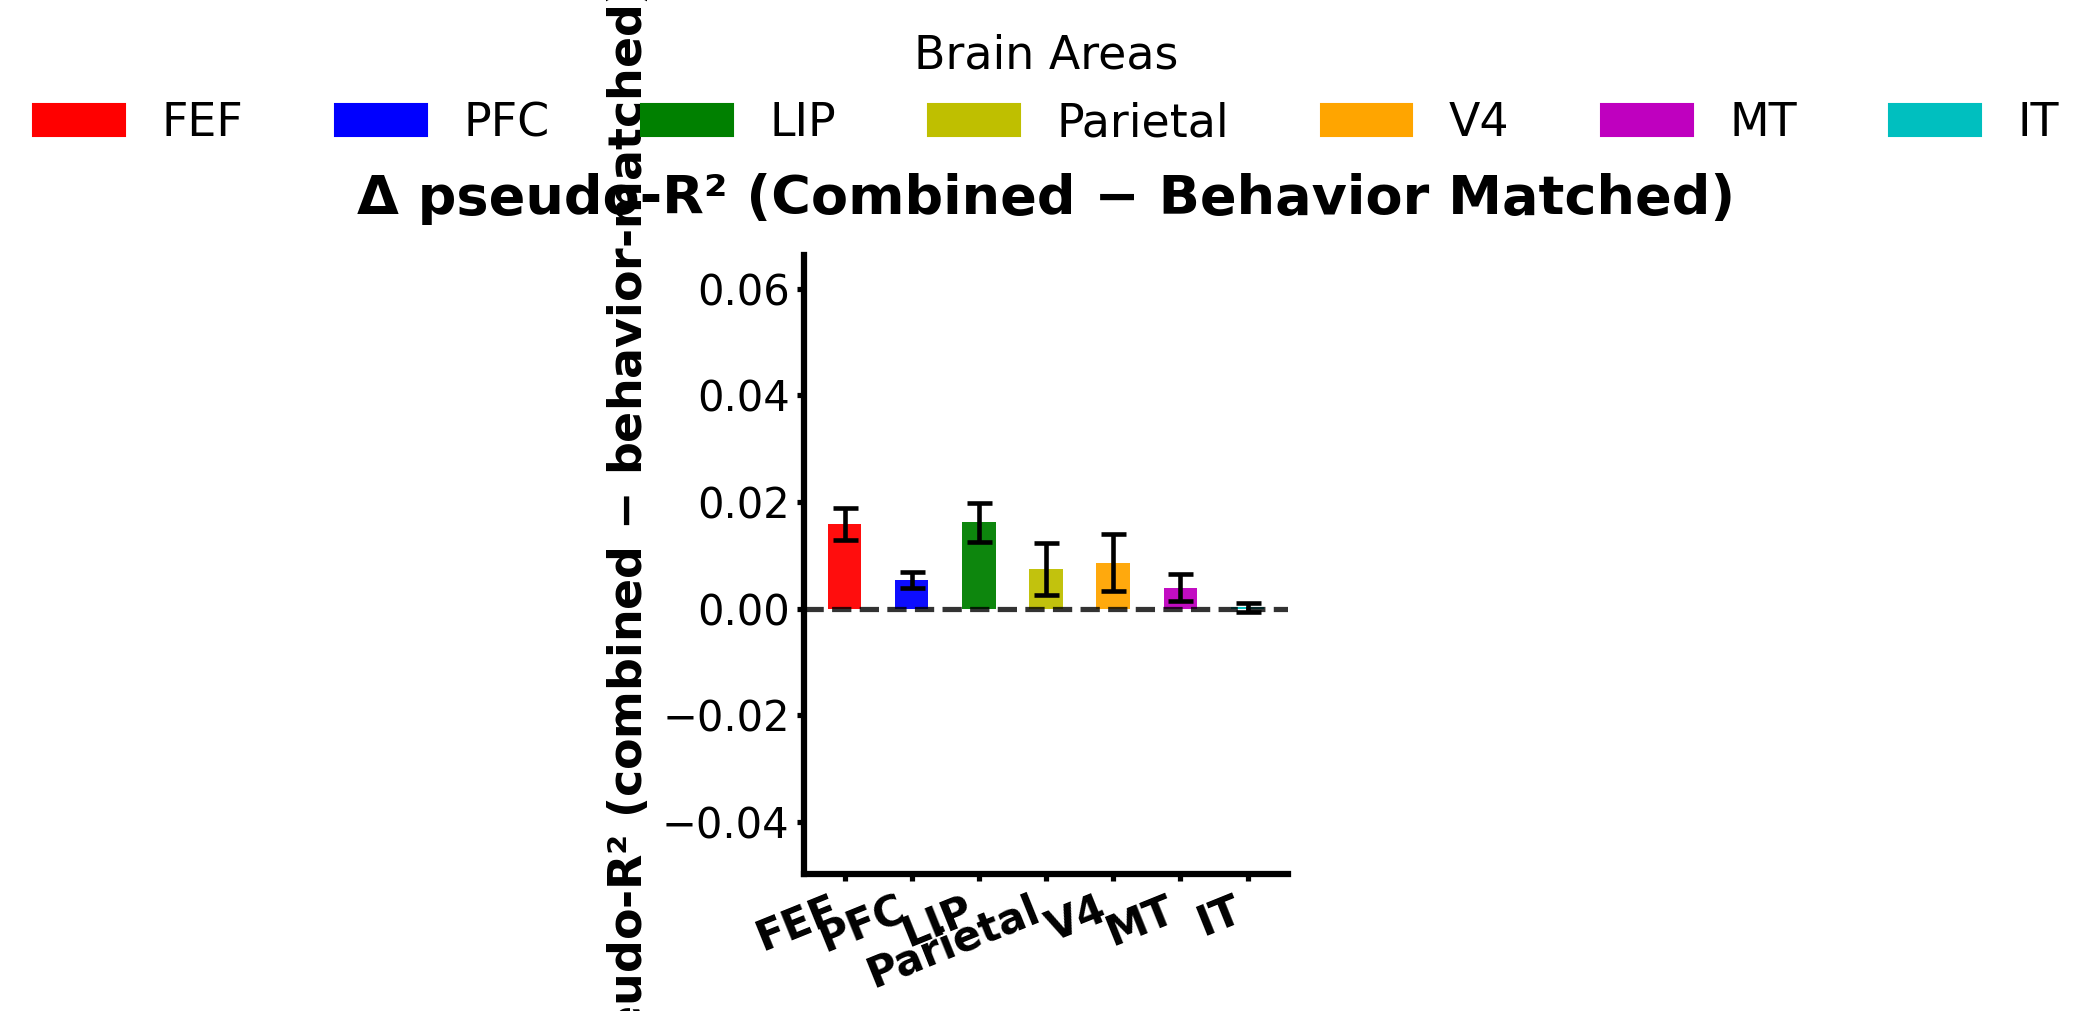

In [40]:
def plot_delta_combined_vs_behavior_matched_poster(
    per_area_stats: Dict[str, Dict[str, Dict[str, np.ndarray]]],
    area_order: List[str] = None,
    title: str = "Extra pseudo-R² of combined vs behavior-matched (session-wise mean ± SEM)"
):
    """
    Poster-ready bar plot of:
        ΔR² = R²_combined − R²_behavior_matched
    Bars are colored by area using user-defined colors.
    """

    # === AREA COLORS PROVIDED BY YOU ===
    area_colors = {
        'PFC': 'b',
        'FEF': 'r',
        'LIP': 'g',
        'Parietal': 'y',
        'IT': 'c',
        'MT': 'm',
        'V4': 'orange'
    }

    plt.style.use("default")

    # === FONT & STYLE ===
    plt.rcParams.update({
        "font.size": 20,
        "axes.titlesize": 26,
        "axes.labelsize": 22,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 22,
        "axes.linewidth": 3,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    })

    areas = area_order if area_order is not None else list(per_area_stats.keys())
    N = len(areas)
    x = np.arange(N)

    # === Compute ΔR² per area ===
    delta_means = []
    delta_sems = []

    for area in areas:
        comb_sess = np.asarray(per_area_stats[area]["combined"]["per_session"], dtype=float)
        behm_sess = np.asarray(per_area_stats[area]["behavior_matched"]["per_session"], dtype=float)

        delta = comb_sess - behm_sess

        finite = np.isfinite(delta)
        if np.any(finite):
            ds = delta[finite]
            mean = float(np.mean(ds))
            sem  = float(np.std(ds, ddof=1) / np.sqrt(ds.size)) if ds.size > 1 else np.nan
        else:
            mean, sem = np.nan, np.nan

        delta_means.append(mean)
        delta_sems.append(sem)

    delta_means = np.array(delta_means, dtype=float)
    delta_sems  = np.array(delta_sems, dtype=float)

    # === FIGURE ===
    fig_width = max(10, 1.4 * N)
    fig_height = 7.5
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=150)

    bar_width = 0.5

    # === Bars (each with its area color) ===
    bars = []
    for i, area in enumerate(areas):
        col = area_colors.get(area, "gray")  # fallback to gray
        bar = ax.bar(
            x[i],
            np.nan_to_num(delta_means[i]),
            width=bar_width,
            color=col,
            edgecolor=None,
            alpha=0.95
        )
        bars.append(bar[0])

    # === Error bars ===
    for i, (m, s, bar) in enumerate(zip(delta_means, delta_sems, bars)):
        if np.isfinite(m):
            ax.errorbar(
                bar.get_x() + bar.get_width() / 2,
                m,
                yerr=s,
                fmt="none",
                ecolor="black",
                elinewidth=2.2,
                capsize=6,
                capthick=2.2
            )

    # === Zero line ===
    ax.axhline(0.0, color="black", lw=2.5, ls="--", alpha=0.8)

    # === Aesthetics ===
    ax.set_xticks(x)
    ax.set_xticklabels(areas, rotation=22, ha="right", fontweight="bold")
    ax.set_ylabel(r"$\Delta$ pseudo-R² (combined − behavior-matched)", fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # === Y limits ===
    finite_vals = delta_means[np.isfinite(delta_means)]
    if finite_vals.size:
        ymin = min(-0.02, np.min(finite_vals) - 0.05)
        ymax = max(0.02, np.max(finite_vals) + 0.05)
    else:
        ymin, ymax = -0.1, 0.1

    ax.set_ylim([ymin, ymax])
    ax.set_xlim([-0.6, N - 0.4])

    # === Legend ===
    handles = []
    labels = []
    for area in areas:
        handles.append(plt.Rectangle((0, 0), 1, 1, color=area_colors.get(area, "gray")))
        labels.append(area)

    ax.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.11),
        ncol=min(7, len(areas)),
        frameon=False,
        title="Brain Areas",
        title_fontsize=22
    )

    plt.tight_layout(pad=1.4)
    plt.show()

plot_delta_combined_vs_behavior_matched_poster(
    per_area_stats,
    area_order=areas_present,
    title="Δ pseudo-R² (Combined − Behavior Matched)"
)
